# Imports

In [6]:
import mis
import metric

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os

# Get data

In [9]:
save_dir = '/grid/klindt/data/Neuro/vinken2023/dataverse_files/data/'

images = loadmat(os.path.join(save_dir, 'images.mat'))
inputs = images['imarray'].copy()
inputs = np.transpose(inputs, (3, 2, 0, 1))
neural = loadmat(os.path.join(save_dir, 'neural.mat'))
activations = neural['R'].copy().T

inputs.shape, activations.shape

((1379, 3, 224, 224), (1379, 449))

# Get metrics and precompute similarities

In [3]:
# get metric: dreamsim
dreamsim = metric.DreamSimMetric()

/grid/klindt/home/klindt/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-07 10:47:01.450944: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-07 10:47:03.581161: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744037223.972498 2946985 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744037224.135820 2946985 cuda_blas.cc:1418

Using cached ./models


Using cache found in ./models/facebookresearch_dino_main
/grid/klindt/home/klindt/.conda/envs/pytorch/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")
/grid/klindt/home/klindt/.conda/envs/pytorch/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [4]:
# precompute embeddings for metric to speed up (significantly)
dreamsim.precompute(inputs, batch_size=256)
print(dreamsim.similarity_matrix.shape)

Embedding images.


100%|██████████| 6/6 [02:52<00:00, 28.82s/it]


Computing similarities.
Dreamsim: Precomputed embeddings and similarities. Now, use precomputed_similarity with indices!
You can also save metric.similarity_matrix and use it to initialize PrecomputedMetric
this is to avoid precomputing next time.


In [7]:
# skipping this, because I already saved the precomputed similarity_matrix

# save the precomputed similarity_matrix to reuse next time (so we only have to do this once)
# np.save(os.path.join(save_dir, 'dreamsim_precomputed.npy'), dreamsim.similarity_matrix)

In [25]:
os.listdir(save_dir)

['neural.mat',
 'lpips_precomputed.npy',
 'lpips_per_layer_precomputed.npy',
 'images.mat',
 'dreamsim_precomputed.npy',
 'reconstructed_images']

In [10]:
# load precomputed similarity_matrix
dreamsim = metric.PrecomputedMetric(
    np.load(os.path.join(save_dir, 'dreamsim_precomputed.npy'))
)

In [11]:
# load LPIPS (per layer), same as above

precomputed = True  # set this to True if it was already precomputed (check save_dir below)

if not precomputed:
    lpips_per_layer = metric.LPIPSMetric('cuda', ret_per_layer=True)
    lpips_per_layer.precompute(inputs, batch_size=64)
    print(lpips_per_layer.similarity_matrix.shape)
    np.save(os.path.join(save_dir, 'lpips_per_layer_precomputed.npy'), lpips_per_layer.similarity_matrix)
else:
    lpips_per_layer = metric.PrecomputedMetric(np.load(os.path.join(save_dir, 'lpips_per_layer_precomputed.npy')))

# Compute MIS

In [12]:
quantiles = np.linspace(0, 0.5, 10)
result = mis.run_psychophysics(
    inputs=inputs,
    activations=activations,
    metrics={'dreamsim': dreamsim, 'lpips_per_layer': lpips_per_layer},
    quantiles=quantiles,
    num_trials=50
)

100%|██████████| 449/449 [01:18<00:00,  5.71it/s]


# Analyze results

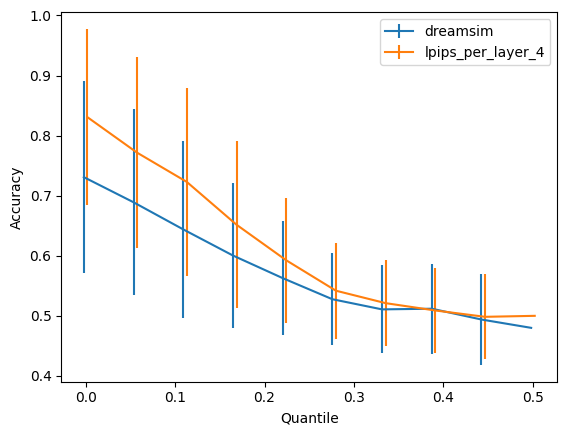

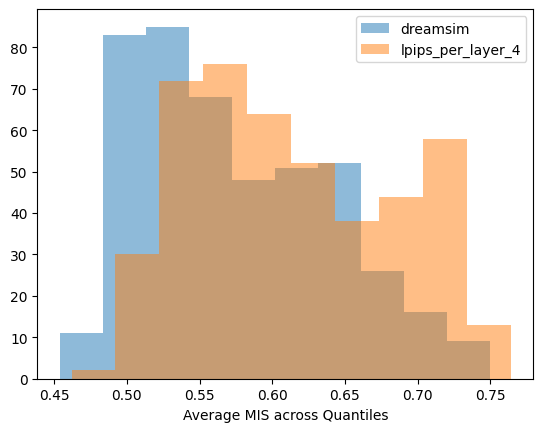

In [24]:
# show results
plt.errorbar(
    quantiles - .002, 
    result['accuracy_dreamsim'].mean(0), 
    result['accuracy_dreamsim'].std(0),
    label='dreamsim'
)
plt.errorbar(
    quantiles + .002, 
    result['accuracy_lpips_per_layer_4'].mean(0), 
    result['accuracy_lpips_per_layer_4'].std(0),
    label='lpips_per_layer_4'
)
plt.xlabel('Quantile')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.hist(result['accuracy_dreamsim'].mean(1), alpha=.5, label='dreamsim')
plt.hist(result['accuracy_lpips_per_layer_4'].mean(1), alpha=.5, label='lpips_per_layer_4')
plt.xlabel('Average MIS across Quantiles')
plt.legend()
plt.show()

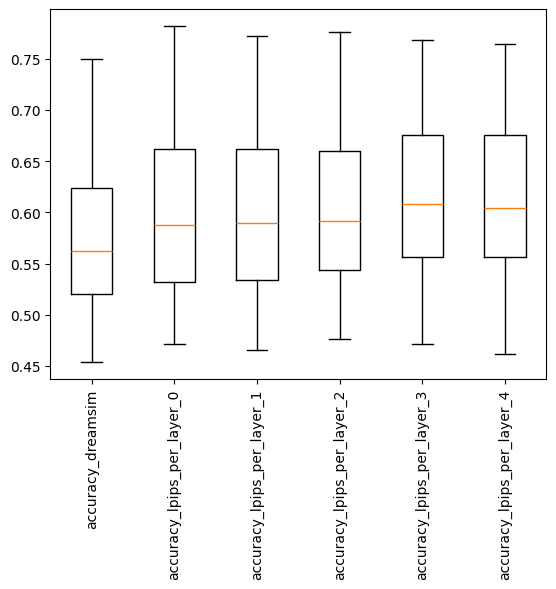

In [15]:
stats, labels = [], []
for key in result:
    if 'accuracy' in key:
        stats.append(result[key].mean(1))
        labels.append(key)

plt.boxplot(stats)
plt.xticks(np.arange(len(stats)) + 1, labels, rotation=90)
plt.show()